## 데이터 불러오기 및 전처리

In [63]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, recall_score,  precision_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [64]:
origin = pd.read_csv(
    "기후에너지환경부.csv",
    encoding="cp949"
)
origin.head()

,분야 및 연도,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
0,총배출량(Gg CO2eq),292097.8,315341.5,343337.6,378532.9,403541.2,433757.3,470241.2,501875.2,431387.6,...,656048.8,684703.4,688035.3,697308.8,692100.7,692576,693612.5,710743.4,727045.2,701370.4
1,순배출량,254424.5,281879.1,310662.4,347664.4,370444.7,402460,435519.1,462376,383326.7,...,601295,631443.4,639994.1,653919.2,647718.7,647012.4,647071.3,668186,684959,661820.1
2,에너지,240294.5,258113.2,278995.6,308499.8,327799.7,352000.7,385582.1,411617.6,351493.3,...,565692.1,594655.1,596004.2,604525,596943.4,600256.4,602213.7,615604.6,632571.9,611499.1
3,A 연료연소,235182.2,253554.5,275205.9,305340.3,325066.6,349613.2,383185.8,409141.4,349141.9,...,561911.8,590614.5,591653.6,600054.7,592851.5,596492.3,598317,611628.1,628144.7,607301.6
4,A 연료연소_1 에너지산업,48351.2,54790.1,62374.9,68765.1,83606.2,91684.7,108977.8,122325.2,106295.2,...,254797.3,262387.6,266405.6,272977.1,258467.4,260499.4,262104.3,269764.3,286398.7,266224.6


In [65]:
import os
os.getcwd()


'c:\\Users\\itwill\\Documents\\main_G\\main\\12월\\파이널프로젝트'

In [66]:
origin.shape
origin.head()
origin.columns
origin.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 31 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   분야 및 연도  144 non-null    object
 1   1990     126 non-null    object
 2   1991     121 non-null    object
 3   1992     122 non-null    object
 4   1993     122 non-null    object
 5   1994     123 non-null    object
 6   1995     123 non-null    object
 7   1996     123 non-null    object
 8   1997     124 non-null    object
 9   1998     124 non-null    object
 10  1999     124 non-null    object
 11  2000     124 non-null    object
 12  2001     124 non-null    object
 13  2002     124 non-null    object
 14  2003     124 non-null    object
 15  2004     124 non-null    object
 16  2005     124 non-null    object
 17  2006     124 non-null    object
 18  2007     124 non-null    object
 19  2008     124 non-null    object
 20  2009     124 non-null    object
 21  2010     125 non-null    object
 22  20

연도칼럼 리스트 만듬

In [67]:
year_cols = origin.columns[1:]  # '1990' ~ '2019'


melt

In [68]:
df_long = origin.melt(
    id_vars='분야 및 연도',
    value_vars=year_cols,
    var_name='연도',
    value_name='배출량'
)


In [69]:
df_long.shape
df_long.head()
df_long.columns
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   분야 및 연도  4320 non-null   object
 1   연도       4320 non-null   object
 2   배출량      3710 non-null   object
dtypes: object(3)
memory usage: 101.4+ KB


In [70]:
df_long['분야'] = df_long['분야 및 연도'].str.strip()


6-1. 연도별 총배출량

In [71]:
yearly = (
    df_long
    .groupby('연도', as_index=False)['배출량']
    .sum()
)


In [72]:
yearly

,연도,배출량
0,1990,292097.8254424.5240294.5235182.248351.236575.3...
1,1991,315341.5281879.1258113.2253554.554790.142684.3...
2,1992,343337.6310662.4278995.6275205.962374.95011211...
3,1993,378532.9347664.4308499.8305340.368765.156338.8...
4,1994,403541.2370444.7327799.7325066.683606.271011.1...
5,1995,433757.3402460352000.7349613.291684.7786881236...
6,1996,470241.2435519.1385582.1383185.8108977.895316....
7,1997,501875.2462376411617.6409141.4122325.2107294.3...
8,1998,431387.6383326.7351493.3349141.9106295.2911141...
9,1999,469368.6413819.4382112.8379577.1116150.2100604...


## 위키피디아

가스별 정의 텍스트 수집

In [98]:
import wikipedia

wikipedia.set_lang("en")

page = wikipedia.page("Greenhouse gas")
text = page.content

print(text[:2000])


ModuleNotFoundError: No module named 'wikipedia'

In [99]:
import wikipedia
wikipedia.set_lang("en")

topics = {
    "Carbon dioxide": "Carbon dioxide",
    "Methane": "Methane",
    "Nitrous oxide": "Nitrous oxide"
}

wiki_text = {}

for key, title in topics.items():
    page = wikipedia.page(title, auto_suggest=False)
    wiki_text[key] = page.content



ModuleNotFoundError: No module named 'wikipedia'

In [ ]:
{
  "Carbon dioxide": "...",
  "Methane": "...",
  "Nitrous oxide": "..."
}


{'Carbon dioxide': '...', 'Methane': '...', 'Nitrous oxide': '...'}

In [ ]:
import wikipedia
wikipedia.set_lang("en")

page = wikipedia.page("Greenhouse gas inventory")
wiki_text_en = page.content


한국어 번역 방법<br>
googletrans

In [ ]:
from deep_translator import GoogleTranslator

def split_text(text, max_length=4000):
    chunks = []
    start = 0
    while start < len(text):
        end = start + max_length
        chunks.append(text[start:end])
        start = end
    return chunks


In [ ]:
chunks = split_text(wiki_text_en, max_length=4000)
len(chunks)


7

In [ ]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='en', target='ko')

translated_chunks = []

for chunk in chunks:
    translated = translator.translate(chunk)
    translated_chunks.append(translated)

wiki_text_ko = "\n".join(translated_chunks)


In [ ]:
formatted_text = wiki_text_ko.replace(". ", ".\n")
print(formatted_text)


온실가스 인벤토리는 다양한 이유로 개발된 온실가스 배출의 배출 인벤토리입니다.
 과학자들은 대기 모델을 개발할 때 자연 및 인위적(인위적) 배출 목록을 도구로 사용합니다.
 정책 입안자들은 인벤토리를 사용하여 배출 감소를 위한 전략과 정책을 개발하고 해당 정책의 진행 상황을 추적합니다.
규제 기관과 기업은 또한 허용 가능한 배출율에 대한 규정 준수 기록을 수립하기 위해 목록에 의존합니다.
 기업, 대중 및 기타 이익 집단은 배출량의 출처와 추세를 더 잘 이해하기 위해 목록을 사용합니다.
다른 대기 배출 인벤토리와 달리 온실가스 인벤토리에는 배출원 범주의 배출량뿐만 아니라 탄소 흡수원에 의한 제거도 포함됩니다.
 이러한 제거를 일반적으로 탄소 격리라고 합니다.
온실가스 인벤토리는 일반적으로 지구 온난화 지수(GWP) 값을 사용하여 다양한 온실가스 배출량을 단일 가중치 배출량 값으로 결합합니다.


== 예시 ==
온실가스 인벤토리의 주요 사례는 다음과 같습니다.

모든 부속서 I 국가는 유엔기후변화협약(UNFCCC)에 따라 온실가스의 연간 배출량과 흡원을 보고해야 합니다.
UNFCCC 및/또는 교토 의정서 당사국인 국가 정부는 배출원에서 발생하는 모든 인위적 온실가스 배출 및 흡수원에서 제거되는 양에 대한 연간 목록을 제출해야 합니다.
교토 의정서에는 의정서 제5조 및 제8조 준수 여부를 결정하기 위한 국가 목록 시스템, 목록 보고 및 연간 목록 검토에 대한 추가 요구 사항이 포함되어 있습니다.
교토 의정서의 청정 개발 메커니즘에 따른 프로젝트 개발자는 프로젝트 기준의 일부로 목록을 준비합니다.


== 온실가스 배출회계 ==

온실가스 배출 회계는 특정 기간 동안 정부(보통 국가, 때로는 지역 또는 도시)가 배출한 온실가스(GHG)의 양을 측정하는 것입니다.
이러한 조치는 기후 과학 및 기후 정책을 수행하는 데 사용됩니다.
GHG 배출량을 측정하는 방법에는 생산 기반(영토 기반이라고도 함)과 소비 기반이라는 두 가지 주요 상충되는 방법이 있습니다.
기후 변화에

## 1️⃣ 📊 연도별 총배출량 시계열 분석

1-1. 연도별 총배출량 집계

In [45]:
yearly_total = (
    df_long
    .groupby('연도', as_index=False)['배출량']
    .sum()
    .sort_values('연도')
)


In [46]:
yearly_total

,연도,배출량
0,1990,292097.8254424.5240294.5235182.248351.236575.3...
1,1991,315341.5281879.1258113.2253554.554790.142684.3...
2,1992,343337.6310662.4278995.6275205.962374.95011211...
3,1993,378532.9347664.4308499.8305340.368765.156338.8...
4,1994,403541.2370444.7327799.7325066.683606.271011.1...
5,1995,433757.3402460352000.7349613.291684.7786881236...
6,1996,470241.2435519.1385582.1383185.8108977.895316....
7,1997,501875.2462376411617.6409141.4122325.2107294.3...
8,1998,431387.6383326.7351493.3349141.9106295.2911141...
9,1999,469368.6413819.4382112.8379577.1116150.2100604...


*국가 온실가스 절대 규모 추세*<br>
*감축정책 효과, 구조 변화의 1차 지표*

6-2. 분야별 구조 변화

In [77]:
sector_year = (
    df_long
    .groupby(['연도', '분야'], as_index=False)['배출량']
    .sum()
)


In [78]:
sector_year["분야"].value_counts()

분야
A 광물산업                   30
A 광물산업_1 시멘트생산           30
A 광물산업_2 석회생산            30
A 광물산업_3 석회석 및 백운석 소비    30
A 광물산업_4 소다회 생산 및 소비     30
                         ..
산업공정                     30
순배출량                     30
에너지                      30
총배출량(Gg CO2eq)           30
폐기물                      30
Name: count, Length: 144, dtype: int64

In [79]:
sector_year['비중'] = (
    sector_year['배출량'] /
    sector_year.groupby('연도')['배출량'].transform('sum')
)


TypeError: can only concatenate str (not "int") to str

In [80]:
import numpy as np

df = df_long.copy()

# 원본 문자열
df['raw'] = df['분야 및 연도']

# 앞쪽 공백 개수 → 계층 판단
df['indent'] = df['raw'].str.len() - df['raw'].str.lstrip().str.len()

# 텍스트 정리
df['label'] = df['raw'].str.strip()

df


,분야 및 연도,연도,배출량,분야,raw,indent,label
0,총배출량(Gg CO2eq),1990,292097.8,총배출량(Gg CO2eq),총배출량(Gg CO2eq),0,총배출량(Gg CO2eq)
1,순배출량,1990,254424.5,순배출량,순배출량,0,순배출량
2,에너지,1990,240294.5,에너지,에너지,0,에너지
3,A 연료연소,1990,235182.2,A 연료연소,A 연료연소,0,A 연료연소
4,A 연료연소_1 에너지산업,1990,48351.2,A 연료연소_1 에너지산업,A 연료연소_1 에너지산업,0,A 연료연소_1 에너지산업
...,...,...,...,...,...,...,...
4315,C 국제벙커링 및 다국적 작전,2019,42103.37,C 국제벙커링 및 다국적 작전,C 국제벙커링 및 다국적 작전,0,C 국제벙커링 및 다국적 작전
4316,C 국제벙커링 및 다국적 작전_1 벙커링,2019,42103.37,C 국제벙커링 및 다국적 작전_1 벙커링,C 국제벙커링 및 다국적 작전_1 벙커링,0,C 국제벙커링 및 다국적 작전_1 벙커링
4317,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,2019,15925.65,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,0,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공
4318,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,2019,26177.73,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,0,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운


In [82]:
df['대분류'] = np.where(df['indent'] == 0, df['label'], np.nan)
df['대분류'] = df['대분류'].ffill()

df['중분류'] = np.where(df['indent'] > 0, df['label'], np.nan)

df


,분야 및 연도,연도,배출량,분야,raw,indent,label,대분류,중분류
0,총배출량(Gg CO2eq),1990,292097.8,총배출량(Gg CO2eq),총배출량(Gg CO2eq),0,총배출량(Gg CO2eq),총배출량(Gg CO2eq),NaN
1,순배출량,1990,254424.5,순배출량,순배출량,0,순배출량,순배출량,NaN
2,에너지,1990,240294.5,에너지,에너지,0,에너지,에너지,NaN
3,A 연료연소,1990,235182.2,A 연료연소,A 연료연소,0,A 연료연소,A 연료연소,NaN
4,A 연료연소_1 에너지산업,1990,48351.2,A 연료연소_1 에너지산업,A 연료연소_1 에너지산업,0,A 연료연소_1 에너지산업,A 연료연소_1 에너지산업,NaN
...,...,...,...,...,...,...,...,...,...
4315,C 국제벙커링 및 다국적 작전,2019,42103.37,C 국제벙커링 및 다국적 작전,C 국제벙커링 및 다국적 작전,0,C 국제벙커링 및 다국적 작전,C 국제벙커링 및 다국적 작전,NaN
4316,C 국제벙커링 및 다국적 작전_1 벙커링,2019,42103.37,C 국제벙커링 및 다국적 작전_1 벙커링,C 국제벙커링 및 다국적 작전_1 벙커링,0,C 국제벙커링 및 다국적 작전_1 벙커링,C 국제벙커링 및 다국적 작전_1 벙커링,NaN
4317,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,2019,15925.65,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,0,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,NaN
4318,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,2019,26177.73,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,0,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,NaN


In [84]:
df['indent'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
4315    0
4316    0
4317    0
4318    0
4319    0
Name: indent, Length: 4320, dtype: int64>

2-2. 전·후 구간 정의

In [ ]:
df['연도'] = df['연도'].astype(int)

df['시기'] = np.where(
    df['연도'] < 2008, '2008 이전',
    np.where(df['연도'] < 2020, '2008~2019', '2020 이후')
)


2-3. 대분류 기준 구조 비교

In [ ]:
policy_compare = (
    df
    .groupby(['시기', '대분류'], as_index=False)['배출량']
    .sum()
)

policy_compare['비중'] = (
    policy_compare['배출량'] /
    policy_compare.groupby('시기')['배출량'].transform('sum')
)


TypeError: can only concatenate str (not "int") to str

에러가나서 문자열을 숫자로 강제변환

In [85]:
df['배출량'] = (
    df['배출량']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('-', '', regex=False)
    .str.strip()
)

df['배출량'] = pd.to_numeric(df['배출량'], errors='coerce')


In [86]:
df['배출량'].dtype
# float64 여야 정상


dtype('float64')

policy코드

In [88]:
policy_compare = (
    df
    .groupby(['시기', '대분류'], as_index=False)['배출량']
    .sum()
)

policy_compare['비중'] = (
    policy_compare['배출량'] /
    policy_compare.groupby('시기')['배출량'].transform('sum')
)


KeyError: '시기'

## 연도별 총배출량

In [89]:
ts = (
    df
    .groupby('연도', as_index=False)['배출량']
    .sum()
    .sort_values('연도')
)


시계열 시각화 (추세 확인)

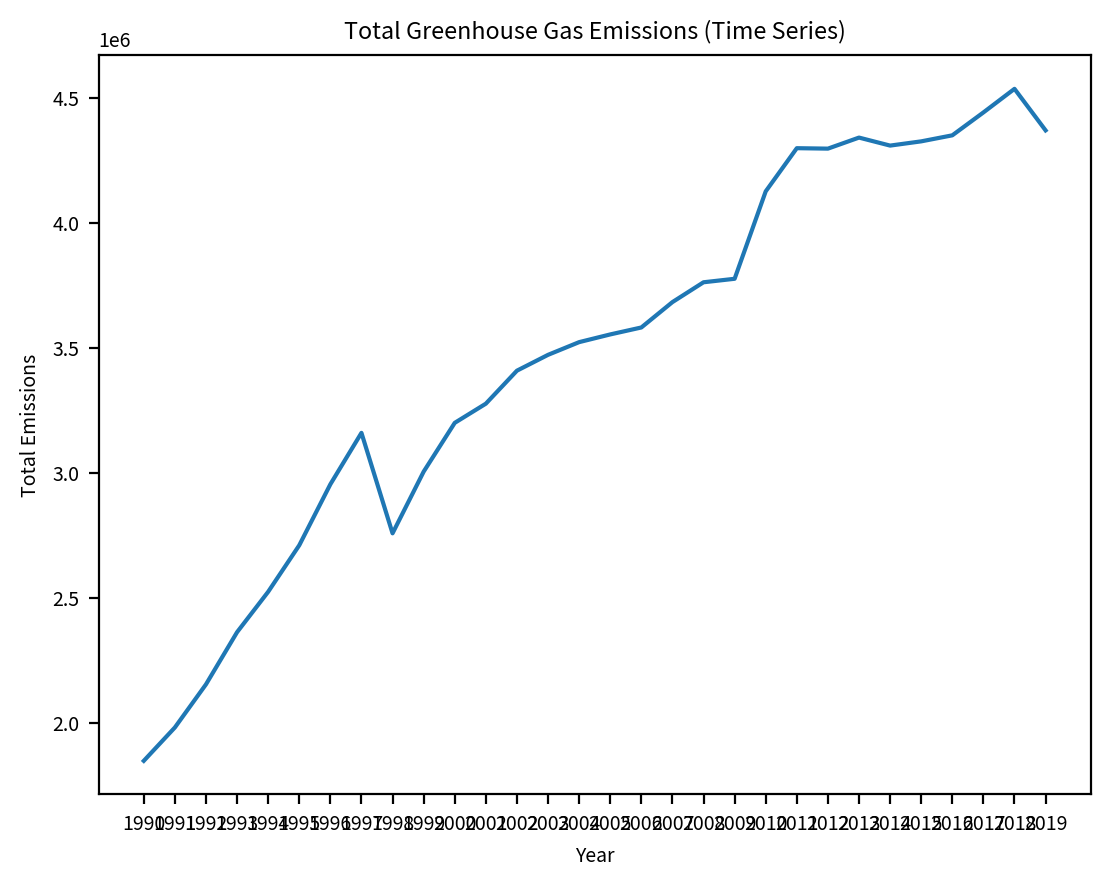

In [90]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ts['연도'], ts['배출량'])
plt.xlabel('Year')
plt.ylabel('Total Emissions')
plt.title('Total Greenhouse Gas Emissions (Time Series)')
plt.show()


## 2015 ~ 2020년도 배출량 데이터만 필터링

In [93]:
mask = (ts['연도'] >= 2015) & (ts['연도'] <= 2020)
ts_2015_2020 = ts.loc[mask]

TypeError: '>=' not supported between instances of 'str' and 'int'

In [ ]:
ts_2015_2020

,연도,배출량
25,2015,4325130.10
26,2016,4349253.75
27,2017,4440775.18
28,2018,4535188.02
29,2019,4369041.82


| 그룹          | 포함 가스           | 특징                |
| ----------- | --------------- | ----------------- |
| **CO₂ 계열**  | CO₂             | 배출량 최대, 구조적 감축 핵심 |
| **CH₄ 계열**  | CH₄             | 단기 고위험, 농업·폐기물    |
| **N₂O 계열**  | N₂O             | 농업 기원, 고 GWP      |
| **F-gases** | HFCs, PFCs, SF₆ | 소량·초고위험           |


## 해당 기간 평균 배출량 계산

In [94]:
ts['배출량'].isna().sum()


np.int64(0)

In [95]:
ts['배출량'].dtype


dtype('float64')

In [ ]:
avg_2015_2020 = ts_2015_2020['배출량'].mean()
avg_2015_2020
print(f"2015~2020년 평균 배출량: {avg_2015_2020:,.0f}")

2015~2020년 평균 배출량: 4,403,878


_2015년~2020년까지의 평균 온실가스 배출량은 약 440만 톤 수준으로 나타남_

In [96]:
def gas_group(category):
    if any(x in category for x in ['연료연소', '에너지', '산업공정']):
        return 'CO2'
    elif any(x in category for x in ['장내발효', '가축분뇨', '폐기물매립', '탈루']):
        return 'CH4'
    elif any(x in category for x in ['농경지토양', '산림지', '습지']):
        return 'N2O'
    elif any(x in category for x in ['할로카본', '육불화황', 'SF6']):
        return 'F-gases'
    else:
        return '기타'


In [113]:
df

,분야 및 연도,연도,배출량,분야,raw,indent,label,대분류,중분류,가스그룹
0,총배출량(Gg CO2eq),1990,292097.80,총배출량(Gg CO2eq),총배출량(Gg CO2eq),0,총배출량(Gg CO2eq),총배출량(Gg CO2eq),NaN,기타
1,순배출량,1990,254424.50,순배출량,순배출량,0,순배출량,순배출량,NaN,기타
2,에너지,1990,240294.50,에너지,에너지,0,에너지,에너지,NaN,CO2
3,A 연료연소,1990,235182.20,A 연료연소,A 연료연소,0,A 연료연소,A 연료연소,NaN,CO2
4,A 연료연소_1 에너지산업,1990,48351.20,A 연료연소_1 에너지산업,A 연료연소_1 에너지산업,0,A 연료연소_1 에너지산업,A 연료연소_1 에너지산업,NaN,CO2
...,...,...,...,...,...,...,...,...,...,...
4315,C 국제벙커링 및 다국적 작전,2019,42103.37,C 국제벙커링 및 다국적 작전,C 국제벙커링 및 다국적 작전,0,C 국제벙커링 및 다국적 작전,C 국제벙커링 및 다국적 작전,NaN,기타
4316,C 국제벙커링 및 다국적 작전_1 벙커링,2019,42103.37,C 국제벙커링 및 다국적 작전_1 벙커링,C 국제벙커링 및 다국적 작전_1 벙커링,0,C 국제벙커링 및 다국적 작전_1 벙커링,C 국제벙커링 및 다국적 작전_1 벙커링,NaN,기타
4317,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,2019,15925.65,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,0,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,C 국제벙커링 및 다국적 작전_1 벙커링_a 국제 항공,NaN,기타
4318,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,2019,26177.73,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,0,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,C 국제벙커링 및 다국적 작전_1 벙커링_b 국제 해운,NaN,기타


In [110]:
cat = df['가스그룹'] = df['분야'].apply(gas_group)
cat.value_counts()


분야
기타         1620
CO2         930
CH4         930
N2O         450
F-gases     390
Name: count, dtype: int64

### IPCC부문별 "연도 시계열 집계"

In [114]:
ipcc_ts = (
    df
    .dropna(subset=['배출량'])
    .groupby(['연도', '분야'], as_index=False)['배출량']
    .sum()
)
